#  Clinicial Text Mining for Disease Prediction

## 1. Install libraries (run once in Colab)

In [ ]:
!pip install -q scispacy spacy scikit-learn pandas matplotlib seaborn joblib
!pip install -q en_core_sci_sm
print("Installed packages.")

ERROR: Could not find a version that satisfies the requirement en_core_sci_sm (from versions: none)
ERROR: No matching distribution found for en_core_sci_sm
Installed packages.


## 2. Imports

In [ ]:
import pandas as pd
import spacy
import scispacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import numpy as np
print("Imports ready.")

Imports ready.


## 3. Upload mtsamples.csv(or csv)

In [ ]:
from google.colab import files
import io

print("Please upload your mtsamples.csv file (it should contain 'transcription' and 'medical_specialty' columns).")
uploaded = files.upload()

df = None
for fname in uploaded:
    print("Uploaded file:", fname)
    df = pd.read_csv(io.BytesIO(uploaded[fname]))
    print("Columns found:", df.columns.tolist())
#Auto-detect expected columns
text_col = None
label_col = None
if df is not None:
  if 'transcription' in df.columns:
    text_col = 'transcription'
  elif 'abstract' in df.columns:
    text_col ='abstract'
  elif 'text' in df.columns:
    text_col = 'text'
  else:
      #pick the longest text-like column
      obj_cols = [c for c in df.columns if df[c].dtype == object]
      if obj_cols:
        text_col = max(obj_cols, key=lambda c: df[c].astype(str).str.len().median())

  if 'medical_specialty' in df.columns:
    label_col = 'medical_specialty'
  elif 'label' in df.columns:
    label_col = 'label'
  elif 'disease' in df.columns:
    label_col = 'disease'

print("Detected text column:", text_col)
print("Detected label column:", label_col)

#prepare df with standard columns 'text' and 'label'
if df is not None and text_col is not None:
  df = df.rename(columns={text_col: 'text'})
else:
  raise ValueError("No text-like column detected. Please ensure 'transcription' is present.")

if label_col is not None:
  df = df.rename (columns={label_col: 'label'})
else:
  # create empty label column: training will be skipped
  df['label'] = None
  print("Warning : No label column detected")

print("Dataset preview:")
df.head()

Please upload your mtsamples.csv file (it should contain 'transcription' and 'medical_specialty' columns).


Saving mtsamples.csv to mtsamples (2).csv
Uploaded file: mtsamples (2).csv
Columns found: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
Detected text column: transcription
Detected label column: medical_specialty
Dataset preview:


,Unnamed: 0,description,label,sample_name,text,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## 4. Preprocess Text (SciSpacy)

In [ ]:
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
    print("SpaCy model loaded.")
except OSError:
    print("SpaCy model not found. Please ensure it's installed.")
    # Fallback or error handling could be added here if needed

def preprocess(text):
    doc = nlp(str(text).lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].astype(str).apply(preprocess)
print("Preprocessing done. Here are examples:")
df[['text','clean_text']].head()

SpaCy model loaded.
Preprocessing done. Here are examples:


,text,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective year old white female present compl...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history difficulty climb stair di...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history present illness see abc today pleasant...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode leave atrial enlargement leave atrial...
4,1. The left ventricular cavity size and wall ...,left ventricular cavity size wall thickness ap...


## 5. Train Logistic Regression Model and TF-IDF vectorization

Model trained on uploaded dataset.
                                precision    recall  f1-score   support

          Allergy / Immunology       0.00      0.00      0.00         2
                       Autopsy       0.00      0.00      0.00         2
                    Bariatrics       0.00      0.00      0.00         5
    Cardiovascular / Pulmonary       0.27      0.29      0.28       112
                  Chiropractic       0.00      0.00      0.00         4
    Consult - History and Phy.       0.27      0.56      0.36       155
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         8
                     Dentistry       0.00      0.00      0.00         8
                   Dermatology       0.00      0.00      0.00         9
          Diets and Nutritions       0.00      0.00      0.00         3
             Discharge Summary       0.25      0.25      0.25        32
          ENT - Otolaryngology       0.29      0.17      0.22        29
        Emergency Room Repor

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


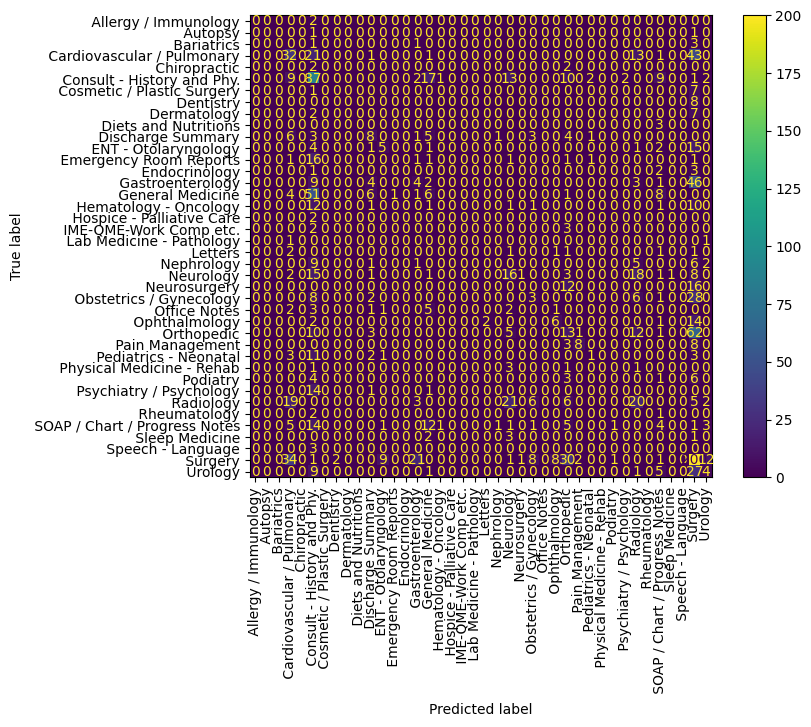

In [ ]:
if df is not None and 'label' in df.columns and not df['label'].isnull().all():
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X = vectorizer.fit_transform(df['clean_text'])
    y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if len(y.unique())>1 else None)
    model = LogisticRegression(max_iter=500)
    model.fit(X_train, y_train)
    print("Model trained on uploaded dataset.")

    # Evaluate
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique()))
    fig, ax = plt.subplots(figsize=(8,6))
    disp.plot(ax=ax, xticks_rotation=90)
    plt.show()
else:
    print("No valid dataset with labels to train model.")

## 6. Predict a New transcription(Demo)

In [ ]:
if df is not None and 'label' in df.columns and not df['label'].isnull().all():
    sample_text = ["Patients presented with severe chest pain, diaphoresis and shortness of breath suggesting mycardial infarction."]
    sample_clean_text = preprocess(sample_text[0])
    sample_vec = vectorizer.transform([sample_clean_text])
    print("Predicted label:", model.predict(sample_vec)[0])
else:
    print("No trained model available for prediction.")

Predicted label:  Cardiovascular / Pulmonary


## 7. Visualize Top Words per Disease



In [ ]:
if df is not None and 'label' in df.columns and not df['label'].isnull().all():
    feature_names = np.array(vectorizer.get_feature_names_out())
    classes = sorted(df['label'].unique())
    n_top = 10
    fig, axes = plt.subplots(len(classes), 1, figsize=(10, 4*len(classes)))
    if len(classes) == 1:
        axes = [axes]
    for i, label in enumerate(classes):
        # find coefficient for this class
        coef = model.coef_[i] if model.coef_.shape[0] == len(classes) else model.coef_[0]
        # get top positive coefficients
        top_idx = np.argsort(coef)[-n_top:]
        top_features = feature_names[top_idx]
        top_values = coef[top_idx]
        axes[i].barh(top_features, top_values)
        axes[i].set_title(f"Top words for {label}")
    plt.tight_layout()
    plt.show()
else:
    print("No trained model to visualize top words.")

## 8. Save Model and Vectorizer

In [ ]:
if df is not None and 'label' in df.columns and not df['label'].isnull().all():
    os.makedirs('/mnt/data/artifacts', exist_ok=True)
    joblib.dump(model, '/mnt/data/artifacts/logistic_model_uploaded.joblib')
    joblib.dump(vectorizer, '/mnt/data/artifacts/tfidf_vectorizer_uploaded.joblib')
    print("Saved Model and vectorizer saved to /mnt/data/artifacts/")
else:
    print("No trained model to save.")

Saved Model and vectorizer saved to /mnt/data/artifacts/
